In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("drug200.xls")
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


## Converting categorical values into numerical with label encoding as one-hot encoding will increase multiple columns

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [5]:
df["Gender"] = le.fit_transform(df["Sex"])
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Gender
0,23,F,HIGH,HIGH,25.355,drugY,0
1,47,M,LOW,HIGH,13.093,drugC,1
2,47,M,LOW,HIGH,10.114,drugC,1
3,28,F,NORMAL,HIGH,7.798,drugX,0
4,61,F,LOW,HIGH,18.043,drugY,0


In [6]:
df = df.drop(columns=["Sex"], axis=1)
df.head()

,Age,BP,Cholesterol,Na_to_K,Drug,Gender
0,23,HIGH,HIGH,25.355,drugY,0
1,47,LOW,HIGH,13.093,drugC,1
2,47,LOW,HIGH,10.114,drugC,1
3,28,NORMAL,HIGH,7.798,drugX,0
4,61,LOW,HIGH,18.043,drugY,0


In [7]:
df["Blood Pressure"] = le.fit_transform(df["BP"])
df.head()

,Age,BP,Cholesterol,Na_to_K,Drug,Gender,Blood Pressure
0,23,HIGH,HIGH,25.355,drugY,0,0
1,47,LOW,HIGH,13.093,drugC,1,1
2,47,LOW,HIGH,10.114,drugC,1,1
3,28,NORMAL,HIGH,7.798,drugX,0,2
4,61,LOW,HIGH,18.043,drugY,0,1


In [8]:
df = df.drop(columns=["BP"], axis=1)
df.head()

,Age,Cholesterol,Na_to_K,Drug,Gender,Blood Pressure
0,23,HIGH,25.355,drugY,0,0
1,47,HIGH,13.093,drugC,1,1
2,47,HIGH,10.114,drugC,1,1
3,28,HIGH,7.798,drugX,0,2
4,61,HIGH,18.043,drugY,0,1


In [9]:
df["Cholesterol level"] = le.fit_transform(df["Cholesterol"])
df

,Age,Cholesterol,Na_to_K,Drug,Gender,Blood Pressure,Cholesterol level
0,23,HIGH,25.355,drugY,0,0,0
1,47,HIGH,13.093,drugC,1,1,0
2,47,HIGH,10.114,drugC,1,1,0
3,28,HIGH,7.798,drugX,0,2,0
4,61,HIGH,18.043,drugY,0,1,0
...,...,...,...,...,...,...,...
195,56,HIGH,11.567,drugC,0,1,0
196,16,HIGH,12.006,drugC,1,1,0
197,52,HIGH,9.894,drugX,1,2,0
198,23,NORMAL,14.020,drugX,1,2,1


In [10]:
df = df.drop(columns=["Cholesterol"], axis=1)
df.head()

,Age,Na_to_K,Drug,Gender,Blood Pressure,Cholesterol level
0,23,25.355,drugY,0,0,0
1,47,13.093,drugC,1,1,0
2,47,10.114,drugC,1,1,0
3,28,7.798,drugX,0,2,0
4,61,18.043,drugY,0,1,0


In [11]:
df["Drug OP"] = le.fit_transform(df["Drug"])
df.head()

,Age,Na_to_K,Drug,Gender,Blood Pressure,Cholesterol level,Drug OP
0,23,25.355,drugY,0,0,0,4
1,47,13.093,drugC,1,1,0,2
2,47,10.114,drugC,1,1,0,2
3,28,7.798,drugX,0,2,0,3
4,61,18.043,drugY,0,1,0,4


In [12]:
df = df.drop(columns=["Drug"], axis=1)
df.head()

,Age,Na_to_K,Gender,Blood Pressure,Cholesterol level,Drug OP
0,23,25.355,0,0,0,4
1,47,13.093,1,1,0,2
2,47,10.114,1,1,0,2
3,28,7.798,0,2,0,3
4,61,18.043,0,1,0,4


## Train test split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["Drug OP"], axis=1), df["Drug OP"], test_size=0.3, random_state=42)

In [14]:
X_train.shape

(140, 5)

In [15]:
y_train.shape

(140,)

In [17]:
X_test.shape

(60, 5)

In [18]:
y_test.shape

(60,)

## training the model

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## testing

In [21]:
from sklearn.metrics import accuracy_score

In [23]:
y_pred = tree.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

## Visualizing the tree

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

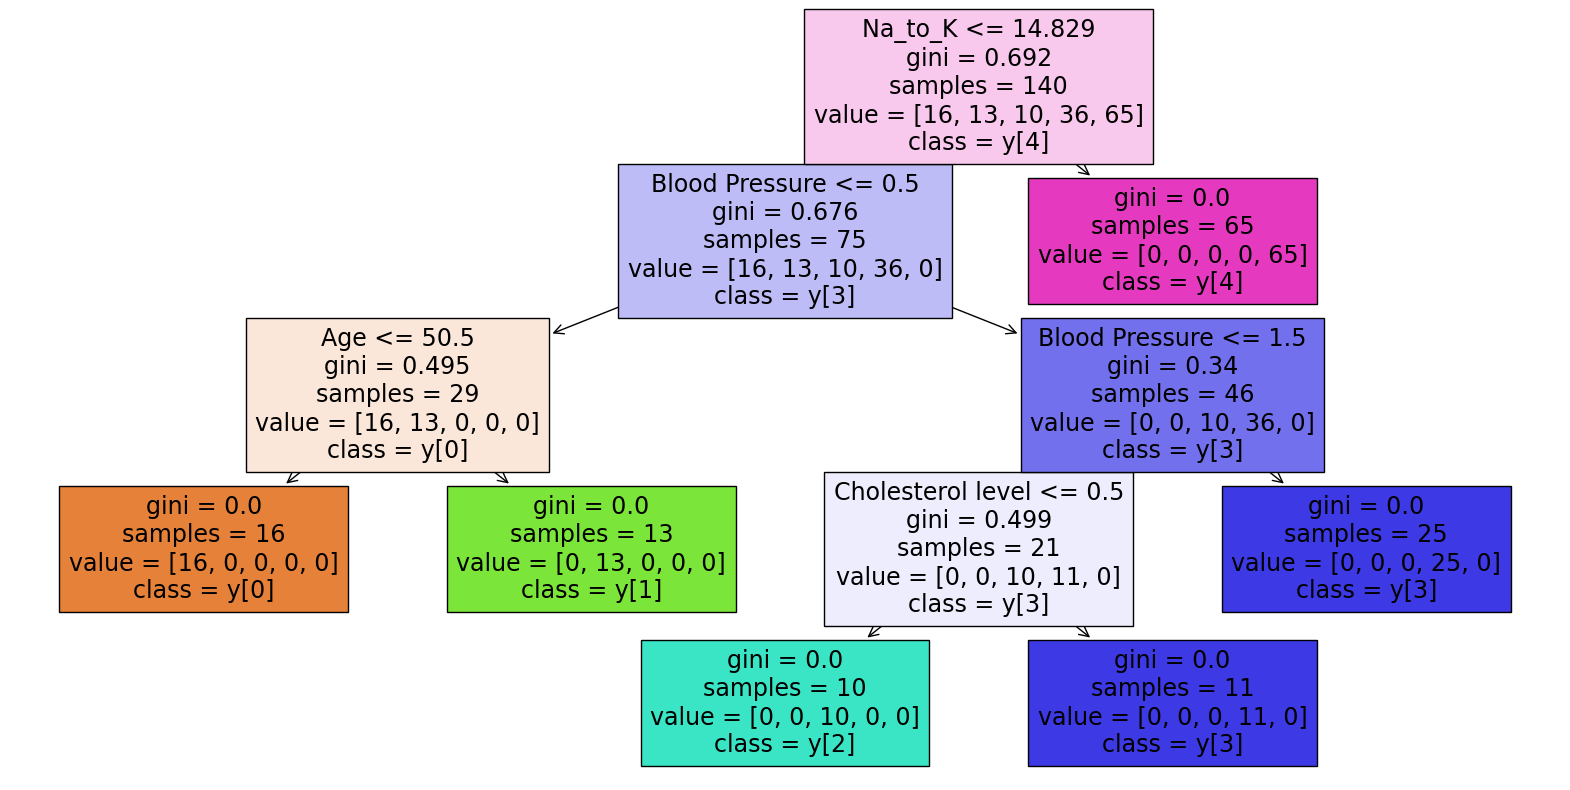

In [28]:
plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=df.columns,
    class_names=True,
    filled=True
)
plt.show()

## Trying different trees

In [27]:
tree2 = DecisionTreeClassifier(max_depth=3)
tree2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
accuracy_score(y_test, tree2.predict(X_test))

0.9

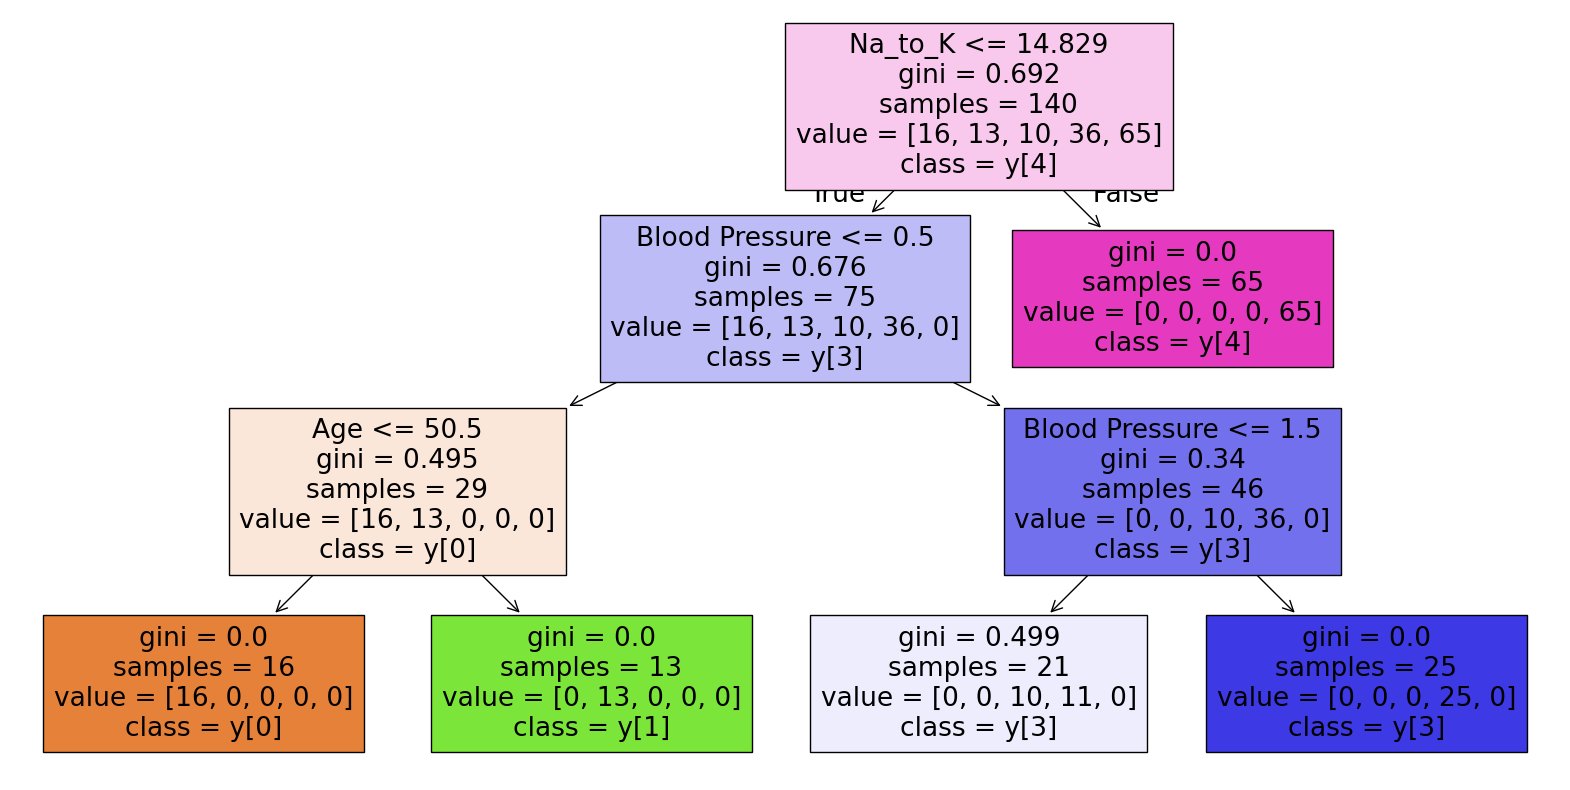

In [31]:
plt.figure(figsize=(20,10))
plot_tree(
    tree2,
    feature_names=df.columns,
    class_names=True,
    filled=True
)
plt.show()